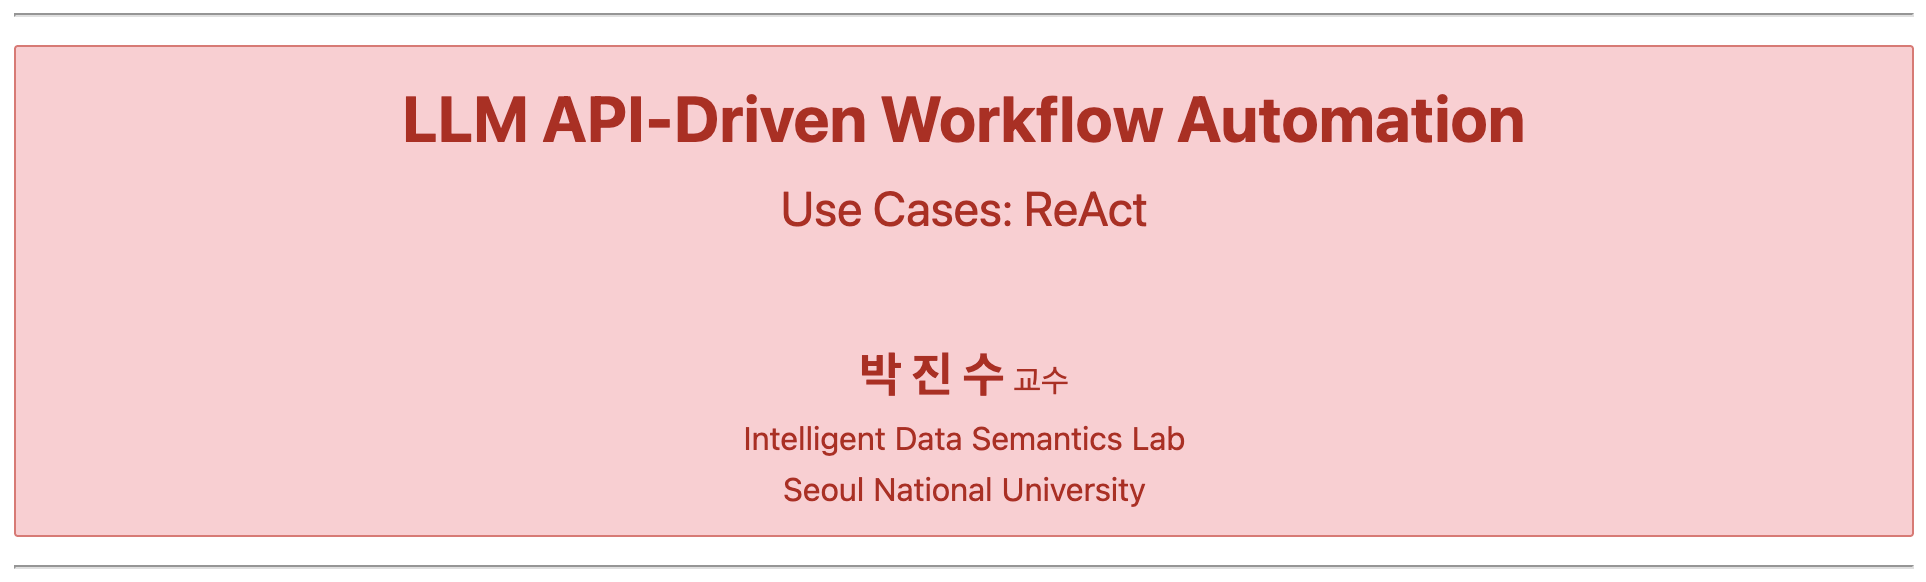

- - -    

- 본 자료는 강의를 위한 목적으로 제작되었습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락해 주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#도우미-함수-가져오기" data-toc-modified-id="도우미-함수-가져오기-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>도우미 함수 가져오기</a></span></li><li><span><a href="#ReAct" data-toc-modified-id="ReAct-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>ReAct</a></span><ul class="toc-item"><li><span><a href="#일반-호출-예시" data-toc-modified-id="일반-호출-예시-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>일반 호출 예시</a></span></li><li><span><a href="#간단한-ReAct-에이전트-정의" data-toc-modified-id="간단한-ReAct-에이전트-정의-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>간단한 ReAct 에이전트 정의</a></span></li><li><span><a href="#ReAct-단순한-질문" data-toc-modified-id="ReAct-단순한-질문-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>ReAct 단순한 질문</a></span></li><li><span><a href="#ReAct-복잡한-질문" data-toc-modified-id="ReAct-복잡한-질문-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>ReAct 복잡한 질문</a></span></li><li><span><a href="#ReAct-에이전트를-루프에-추가" data-toc-modified-id="ReAct-에이전트를-루프에-추가-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>ReAct 에이전트를 루프에 추가</a></span></li></ul></li><li><span><a href="#추론-모델" data-toc-modified-id="추론-모델-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>추론 모델</a></span></li></ul></div>

# 패키지 설치 및 API 설정

**API Key 발급 방법**
- MistralAI: https://drive.google.com/file/d/1eiRVg-hTGhN2SrJz0R7Qsn0ZS6Pw7HHd/view?usp=sharing
- Groq: https://drive.google.com/file/d/1E267hPCwahSbaKWVeCPQp2ksW8T9VsTG/view?usp=sharing
- Google Gemini: https://drive.google.com/file/d/1YLy4B4RkD6Y3HnpScpKd0trPZxKvUsXa/view?usp=sharing
- Anthropic: https://drive.google.com/file/d/1u9q-0_gCc6wmRAXNctQj8ApLRhOtYYpX/view?usp=sharing
- OpenAI: https://drive.google.com/file/d/122mEaoTYAYOPehBfChfOkNLHbZrDge3C/view?usp=sharing

In [ ]:
!python -m pip install -qU python-dotenv langchain # YOUR LLM package HERE (e.g., ollama 'langchain[ollama]' mistralai 'langchain[mistralai]' groq 'langchain[groq]' google-genai 'langchain[google-genai]' anthropic 'langchain[anthropic]' openai 'langchain[openai]')
print('--- Installation Completed', '-' * 55, '\n')

In [1]:
# 방법 1 (API Key 명칭 수정 후 사용) - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

True

In [1]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

Enter Your LLM API Key:  ········


In [ ]:
# 방법 3 (API Key 명칭 수정 후 사용) - (caution) API 키 노출 주의
import os
os.environ['?????_API_KEY'] = 'YOUR-LLM-API-KEY'

# 도우미 함수 가져오기


In [5]:
# --- utils.py 다운로드
!gdown 1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi -O utils.py

Downloading...
From (original): https://drive.google.com/uc?id=1XVMiJglEyAagR2XgIWXc6qql54AwyFQ8
From (redirected): https://drive.google.com/uc?id=1XVMiJglEyAagR2XgIWXc6qql54AwyFQ8&confirm=t&uuid=8a95bdc2-1a6a-4db5-b670-bae62f348e8e
To: /Users/jinsoopark/Dropbox/_data/document/lecture/notebooks/generative-ai/utils.py
100%|██████████████████████████████████████| 20.0k/20.0k [00:00<00:00, 32.7MB/s]


**<u><font size='+1'>도우미 함수 사용법</font></u>**


**1. get_llm_response**(instruction, user_message, model, messages, **kwargs)
- `instruction`에 시스템 지침을, `user_message`에 사용자 입력을 전달하면 LangChain 기반으로 LLM을 호출해 응답 텍스트를 반환한다.
- `messages`에 LangChain 메시지 객체 리스트(`SystemMessage`, `HumanMessage`, `AIMessage` 등)를 직접 전달할 수도 있다. 이 경우 `instruction`과 `user_message`는 무시된다.
- `model`에 사용할 모델 ID를 전달한다 (예: `'openai:gpt-5.4-mini'`, `'google_genai:gemini-2.5-flash'`, `'anthropic:claude-sonnet-4-5-20250929'`).
    + **<font color='tomato'>이 함수의 기본 모델은 `'google_genai:gemini-3.1-flash-lite'`이다.</font>**
    + LangChain에서 사용할 수 있는 모델 이름(ID)과 형식은 공식 문서에서 확인할 수 있다.
        * https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model
- `**kwargs`로 `temperature`, `max_output_tokens` 등 모델별 추가 파라미터를 전달할 수 있다.
    + 💡 참고: GPT-5를 비롯한 일부 추론 모델은 `temperature` 등 일부 파라미터를 지원하지 않는다.
- Gemini, Claude 등 일부 모델이 반환하는 블록 형태의 응답도 내부에서 자동으로 처리해 순수 텍스트만 반환한다.

**사용 예시**
```python
response = get_llm_response(instruction, user_message) # 기본값이 'google_genai:gemini-3.1-flash-lite'
response = get_llm_response(instruction, user_message, model='google_genai:gemini-3.1-flash-lite')
response = get_llm_response(instruction, user_message, model='openai:gpt-5.4-mini')
response = get_llm_response(instruction, user_message, model='anthropic:claude-haiku-4-5')
```

# ReAct

- - -
**ReAct**
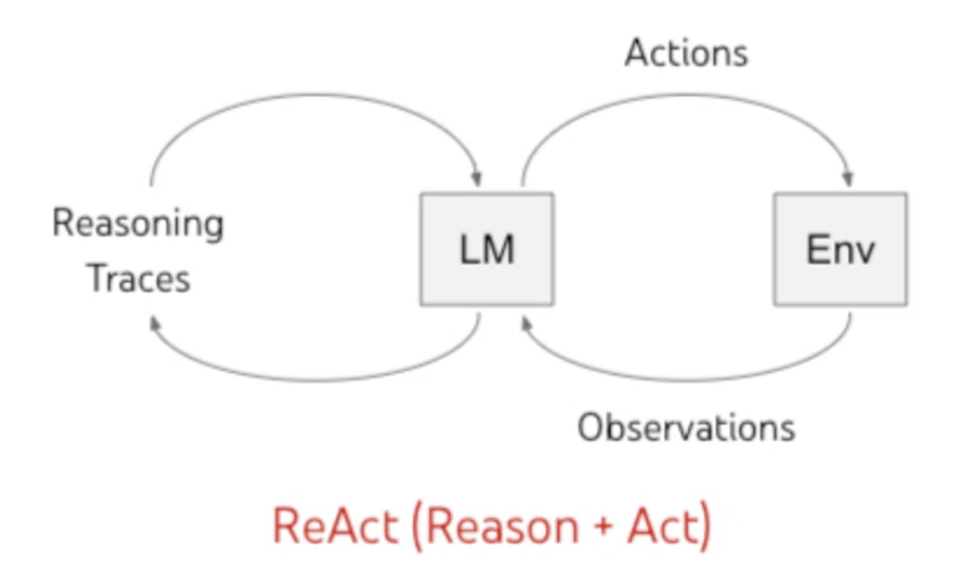
- - -

- - -
**ReAct 참고 논문**
- https://arxiv.org/abs/2210.03629
- - -

**ReAct 기법의 처리 과정**
- 1단계: 결과물을 출력하는데 필요한 행동(act)과 이유(reason)를 추론한다.
- 2단계: 외부 자원의 도움을 받아 행동을 수행하고, 그 결과를 가져온다.
- 3단계: 그 행동에 대한 결과로부터 다음에 수행해야 하는 행동과 이유를 추론한다.
- 4단계: 최종 답변을 생성할 때까지 이 과정을 반복한다.

## 일반 호출 예시

In [2]:
from utils import get_llm_response

user_message = '100,000 KRW는 USD로 얼마나 되나요?'  
response = get_llm_response('', user_message) 
print(response)

현재 환율(2024년 5월 중순 기준, 1달러당 약 1,360~1,370원)을 기준으로 계산하면, **100,000 KRW는 약 73~74 USD** 정도입니다.

환율은 실시간으로 변동되므로, 정확한 금액은 검색창에 **"10만 원 달러"**라고 검색하시거나 금융 앱을 확인하시는 것이 가장 정확합니다. 

*참고: 은행에서 환전하실 때는 환율 수수료가 발생하기 때문에 실제 받으시는 금액은 이보다 조금 적을 수 있습니다.*


## 간단한 ReAct 에이전트 정의

In [3]:
from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from utils import extract_text

class ReActAgent:
    """
    간단한 대화형 ReAct 에이전트 클래스

    이 클래스는 모델 인스턴스와 메시지 히스토리를 내부에 유지한다.

    Attributes:
        model: 초기화한 채팅 모델 객체
        messages: 누적한 메시지 리스트
        instruction: 시스템 메시지로 구성한 지침 메시지로 없을 수 있다.
    """
    def __init__(self, instruction=None, model='google_genai:gemini-3.1-flash-lite'):
                                       # model='google_genai:gemini-flash-latest'
        """
        Agent 인스턴스를 초기화한다.
        모델을 생성하고 메시지 히스토리를 초기화한다.

        Args:
            instruction (str | None): 시스템 프롬프트 문자열이다.
                None이면 시스템 메시지를 추가하지 않는다.
            model (str): 초기화할 모델 식별자

        Returns: None
        """        
        # 모델 객체를 초기화한다.
        self.model = init_chat_model(model)

        # 메시지 히스토리를 초기화한다.
        self.messages = []

        # 시스템 지침 메시지를 구성한다.
        self.instruction = SystemMessage(instruction) if instruction else None
        if self.instruction:
            self.messages.append(self.instruction)

    def __call__(self, message):
        """
        에이전트를 함수처럼 호출해 한 턴의 대화를 수행한다.

        사용자 메시지를 히스토리에 추가하고 모델을 실행한다.
        모델이 생성한 텍스트를 AIMessage로 히스토리에 다시 저장한 뒤 반환한다.

        Args:
            message (str): 사용자 입력 메시지

        Returns:
            str: 모델이 생성한 최종 텍스트 응답
        """
        # 사용자 메시지를 히스토리에 추가한다.
        self.messages.append(HumanMessage(message))

        # 모델을 호출해 텍스트 응답을 얻는다.
        result = self.execute()

        # 텍스트 응답을 AI 메시지로 히스토리에 추가한다.
        self.messages.append(AIMessage(result))
        return result

    def execute(self):
        """
        현재 메시지 히스토리를 기반으로 모델을 실행한다.

        모델을 호출해 결과 객체를 얻고, 텍스트만 추출한다.
        ReAct 패턴에서 '[관찰]:' 구간이 포함되면 그 이전까지만 남긴다.

        Returns:
            str: 후처리까지 완료한 최종 텍스트 응답
        """
        # 모델을 호출해 결과 객체를 얻는다.
        result = self.model.invoke(self.messages)

        # 결과 객체에서 텍스트만 추출한다.
        text = extract_text(result)

        # ReAct 패턴에서 관찰 구간을 잘라 모델 중단처럼 보이게 한다.
        if '\n[관찰]:' in text:
            text = text.split('\n[관찰]:')[0].strip()
        return text

    def show_messages(self):
        """
        현재까지 누적한 메시지 히스토리를 반환한다.

        Returns:
            list: HumanMessage, AIMessage, SystemMessage 객체가
                순서대로 저장된 리스트
        """
        # 누적한 메시지 히스토리를 반환한다.
        return self.messages

In [4]:
# --- 도구는 아니지만 도구처럼 사용 가능한 함수 모음

def calculate(what):
    """
    수식 문자열을 평가하여 결과를 반환한다.

    이 함수는 전달받은 문자열을 Python의 eval로 계산한다.
    간단한 산술 연산 테스트용으로 사용한다.
    보안상 신뢰할 수 없는 입력에는 사용하면 안 된다.

    Args:
        what (str): 계산할 수식 문자열이다.
            예: '2 + 3 * 4'

    Returns:
        float | int: 계산 결과 값이다.
    """
    # 전달받은 수식 문자열을 그대로 eval로 평가한다.
    return eval(what)


def convert_currency(amount, from_currency, to_currency):
    """
    두 통화 간 금액을 고정 환율 기준으로 변환한다.

    이 함수는 내부에 정의한 고정 환율 테이블을 사용한다.
    (from_currency, to_currency) 튜플을 키로 환율을 조회한다.
    환율이 존재하면 변환 결과를 문자열로 반환한다.
    환율이 존재하지 않으면 안내 메시지를 반환한다.

    Args:
        amount (float): 변환할 금액이다.
        from_currency (str): 원본 통화 코드이다.
        to_currency (str): 대상 통화 코드이다.

    Returns:
        str: 변환 결과 또는 오류 메시지 문자열이다.
    """

    # 고정 환율 테이블을 정의한다.
    exchange_rates = {
        # USD <-> EUR
        ('USD', 'EUR'): 0.85,  
        ('EUR', 'USD'): 1 / 0.85, 
        # USD <-> JPY
        ('USD', 'JPY'): 145.0, 
        ('JPY', 'USD'): 1 / 145.0,
        # USD <-> KRW
        ('USD', 'KRW'): 1460.0,
        ('KRW', 'USD'): 1 / 1460.0,
        # EUR <-> JPY
        ('EUR', 'JPY'): 155.0, 
        ('JPY', 'EUR'): 1 / 155.0,
        # EUR <-> KRW
        ('EUR', 'KRW'): 1720.0,
        ('KRW', 'EUR'): 1 / 1720.0,
        # JPY <-> KRW
        ('JPY', 'KRW'): 10.1,
        ('KRW', 'JPY'): 1 / 10.1,
    }
    
    # 요청한 통화 쌍의 환율을 조회한다.
    rate = exchange_rates.get((from_currency, to_currency))

    if rate is not None:  # 환율이 존재하면 변환을 수행한다. 
        converted_amount = amount * rate
        return f'{amount} {from_currency} -> {converted_amount:.2f} {to_currency}'
    else:  # 환율이 존재하지 않으면 안내 메시지를 반환한다. 
        return '주어진 통화에 대한 환율을 사용할 수 없습니다.'

# 예시:
# print(convert_currency(100, 'USD', 'KRW'))  # 출력: 100 USD -> 146000.00 KRW
# print(convert_currency(100000, 'KRW', 'USD'))  # 출력: 100000 KRW -> 68.49 USD

# 사용 가능한 함수들을 이름 기준으로 매핑한다.
known_actions = {
    'calculate': calculate,
    'convert_currency': convert_currency
}

In [5]:
INSTRUCTION = '''당신은 [생각], [행동], [일시 중지], [관찰]의 반복적인 루프를 수행합니다.
루프가 끝나면 [답변]을 출력합니다.
질문에 대한 당신의 생각을 설명하기 위해 [생각] 단계를 사용하십시오.
사용 가능한 작업 중 하나를 실행하기 위해 [행동]을 사용한 다음 [일시 중지]로 돌아갑니다.
[관찰]은 해당 작업을 실행한 결과입니다.
한 번에 하나의 [행동]만 출력하고, [행동]은 반드시 '[행동]: 행동 함수 이름: 전달인자' 형식으로 쓴다(예: [행동]: convert_currency: 100 USD to KRW).

사용 가능한 [행동]은 다음과 같습니다.

calculate:
예: calculate: 4 * 7 / 3
계산을 실행하고 숫자를 반환합니다 - 필요한 경우 부동 소수점 문법을 사용하여 파이썬을 사용합니다.

convert_currency:
예: convert_currency: 100 USD to EUR
주어진 금액을 한 통화에서 다른 통화로 변환하고 변환된 금액을 반환합니다.

[행동]은 위의 두 가지 [행동]만을 기반으로 해야 하며, 외부 소스를 사용해서는 안 됩니다. 

# 예시 세션 
질문: 100 USD는 EUR로 얼마나 되나요?
[생각]: 나는 convert_currency를 사용하여 통화를 변환해야 합니다.
[행동]: convert_currency: 100 USD to EUR
[일시 중지]

당신은 다시 다음 루프를 진행합니다.
[관찰]: 100 USD -> 85 EUR

그런 후 다음과 같이 출력합니다.
[답변]: 100 USD는 85 EUR입니다.
'''

## ReAct 단순한 질문

In [6]:
my_agent = ReActAgent(INSTRUCTION) 

In [7]:
response = my_agent('100,000 KRW는 USD로 얼마나 되나요?')
print(response)

[생각]: 100,000 KRW를 USD로 변환하기 위해 convert_currency 기능을 사용해야 합니다.

[행동]: convert_currency: 100000 KRW to USD
[일시 중지]


In [8]:
response = convert_currency(100000, 'KRW', 'USD')
response

'100000 KRW -> 68.49 USD'

In [9]:
next_prompt = f'[관찰]: {response}'
next_prompt

'[관찰]: 100000 KRW -> 68.49 USD'

In [10]:
my_agent(next_prompt)

'[답변]: 100,000 KRW는 68.49 USD입니다.'

In [11]:
my_agent.show_messages()

[SystemMessage(content="당신은 [생각], [행동], [일시 중지], [관찰]의 반복적인 루프를 수행합니다.\n루프가 끝나면 [답변]을 출력합니다.\n질문에 대한 당신의 생각을 설명하기 위해 [생각] 단계를 사용하십시오.\n사용 가능한 작업 중 하나를 실행하기 위해 [행동]을 사용한 다음 [일시 중지]로 돌아갑니다.\n[관찰]은 해당 작업을 실행한 결과입니다.\n한 번에 하나의 [행동]만 출력하고, [행동]은 반드시 '[행동]: 행동 함수 이름: 전달인자' 형식으로 쓴다(예: [행동]: convert_currency: 100 USD to KRW).\n\n사용 가능한 [행동]은 다음과 같습니다.\n\ncalculate:\n예: calculate: 4 * 7 / 3\n계산을 실행하고 숫자를 반환합니다 - 필요한 경우 부동 소수점 문법을 사용하여 파이썬을 사용합니다.\n\nconvert_currency:\n예: convert_currency: 100 USD to EUR\n주어진 금액을 한 통화에서 다른 통화로 변환하고 변환된 금액을 반환합니다.\n\n[행동]은 위의 두 가지 [행동]만을 기반으로 해야 하며, 외부 소스를 사용해서는 안 됩니다. \n\n# 예시 세션 \n질문: 100 USD는 EUR로 얼마나 되나요?\n[생각]: 나는 convert_currency를 사용하여 통화를 변환해야 합니다.\n[행동]: convert_currency: 100 USD to EUR\n[일시 중지]\n\n당신은 다시 다음 루프를 진행합니다.\n[관찰]: 100 USD -> 85 EUR\n\n그런 후 다음과 같이 출력합니다.\n[답변]: 100 USD는 85 EUR입니다.\n", additional_kwargs={}, response_metadata={}),
 HumanMessage(content='100,000 KRW는 USD로 얼마나 되나요?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='

## ReAct 복잡한 질문

In [12]:
my_agent = ReActAgent(INSTRUCTION) 

In [13]:
question = '미국 달러 200과 유로화 150을 가지고 있는데 이 둘을 합친 원화는 총 얼마인가요?'
response = my_agent(question)
print(response)

[생각]: 먼저 200 USD를 KRW로 변환하고, 150 EUR를 KRW로 변환한 뒤, 두 결과값을 더해야 합니다.

[행동]: convert_currency: 200 USD to KRW
[일시 중지]


In [14]:
next_prompt = f'[관찰]: {convert_currency(200, 'USD', 'KRW')}'
print(next_prompt)

[관찰]: 200 USD -> 292000.00 KRW


In [15]:
response = my_agent(next_prompt)
print(response)

[생각]: 이제 150 EUR를 KRW로 변환해야 합니다.

[행동]: convert_currency: 150 EUR to KRW
[일시 중지]


In [16]:
next_prompt = f'[관찰]: {convert_currency(150, 'EUR', 'KRW')}'
print(next_prompt)

[관찰]: 150 EUR -> 258000.00 KRW


In [17]:
response = my_agent(next_prompt)
print(response)

[생각]: 이제 변환된 두 금액(292,000 KRW + 258,000 KRW)을 합산하여 총액을 구해야 합니다.

[행동]: calculate: 292000.00 + 258000.00
[일시 중지]


In [18]:
next_prompt = f'[관찰]: {calculate('292000.00 + 258000.00')}'
print(next_prompt)

[관찰]: 550000.0


In [19]:
response = my_agent(next_prompt)
print(response)

[답변]: 미국 달러 200과 유로화 150을 합친 원화 금액은 총 550,000 KRW입니다.


## ReAct 에이전트를 루프에 추가

In [20]:
import re
regexp = re.compile(r'\[행동\]\s*:\s*(\w+)\s*:\s*([^\n\[]+)')

In [22]:
def query(question, max_turns=10):
    i = 0
    agent = ReActAgent(INSTRUCTION)
    next_prompt = question
    while i < max_turns:
        i += 1
        response = agent(next_prompt)
        print(response)
        m = regexp.search(response)
        if m:
            action, action_input = m.group(1), m.group(2).strip()
            if action not in known_actions:
                raise Exception('알 수 없는 [행동]: {action}: {action_input}')
            print(f' --- {action} {action_input} 실행')
            if action == 'convert_currency':
                action_input = action_input.split()
                observation = known_actions[action](eval(action_input[0]), action_input[1], action_input[3])
            elif action == 'calculate':
                observation = known_actions[action](action_input)
            print('[관찰]:', observation)
            next_prompt = f'[관찰]: {observation}'
        else:
            return

In [23]:
question = '미국 달러 200과 유로화 150을 가지고 있는데 이 둘을 합친 원화는 총 얼마인가요?'
query(question)

[생각]: 먼저 200 USD를 KRW로 변환하고, 150 EUR를 KRW로 변환한 뒤, 두 금액을 합산해야 합니다.

[행동]: convert_currency: 200 USD to KRW
[일시 중지]
 --- convert_currency 200 USD to KRW 실행
[관찰]: 200 USD -> 292000.00 KRW
[생각]: 이제 150 EUR를 KRW로 변환해야 합니다.

[행동]: convert_currency: 150 EUR to KRW
[일시 중지]
 --- convert_currency 150 EUR to KRW 실행
[관찰]: 150 EUR -> 258000.00 KRW
[생각]: 이제 두 금액을 합산하여 총 원화 금액을 계산합니다.
[행동]: calculate: 292000.00 + 258000.00
[일시 중지]
 --- calculate 292000.00 + 258000.00 실행
[관찰]: 550000.0
[답변]: 미국 달러 200과 유로화 150을 합친 금액은 총 550,000.0 원화입니다.


# 추론 모델 

추론 모델은 모델이 응답의 일부로 거치는 '사고 과정'을 생성하도록 훈련되어있다. 그 결과, 추론 모델은 응답에서 더 강력한 추론 능력을 발휘할 수 있다.

추론 모델을 사용하면 이전 방식(ReAct)처럼 특별히 정교한 프롬프팅 없이도 수준 높은 답변을 얻을 수 있다. 이 기법이 효과적인 이유는 모델이 먼저 질문과 관련된 아이디어(“브레인스토밍” 또는 “생각”)를 스스로 생성하도록 유도하고, 그 결과물을 바탕으로 최종 답변을 구성하기 때문이다.

In [24]:
instruction = '질문에 답을 한 후, 추론 과정을 설명하세요.'
user_message = '''영화 '기생충'(2019)의 공식 포스터 혹은 배급사 보도자료 기준,
주연 배우(카메오, 아역배우 제외) 중에서 촬영 당시 가장 나이가 어렸던 배우는 누구입니까?
한국어로 대답하세요.
''' 
response = get_llm_response(instruction, user_message, model='openai:gpt-5.5')
print(response)

정답은 **박소담**입니다.

### 추론 과정
- 「기생충」의 공식 포스터·배급사 보도자료에서 주연급으로 다뤄지는 성인 주요 배우는 대체로  
  **송강호, 이선균, 조여정, 최우식, 박소담, 이정은, 장혜진, 박명훈** 등입니다.
- 영화 촬영은 **2018년 5월 18일 시작, 2018년 9월 19일 종료**되었습니다.
- 이들 중 젊은 배우들의 생년월일을 비교하면:
  - **최우식**: 1990년 3월 26일생
  - **박소담**: 1991년 9월 8일생

따라서 촬영 당시 박소담은 만 **26세**, 촬영 말미에 만 **27세**가 되었고, 성인 주연 배우 중 가장 나이가 어렸습니다.

※ 단, 보도자료의 전체 주요 출연진에 포함되는 **정지소**를 아역/청소년 역할 배우로 제외하지 않는다면 정지소가 더 어립니다. 하지만 질문처럼 카메오와 아역배우를 제외한 주연 기준이면 **박소담**이 맞습니다.


In [28]:
user_message = '''영화 '기생충'(2019)의 공식 포스터 혹은 배급사 보도자료 기준,
주연 배우(카메오, 아역배우 제외) 중에서 촬영 당시 가장 나이가 어렸던 배우는 누구입니까?
한국어로 대답하세요.
''' 

response = get_llm_response(
    user_message=user_message,
    model='openai:gpt-5.5',
    reasoning_effort='high',  
    verbosity='high'            
)
print(response)

공식 포스터·배급사 보도자료에서 주연급으로 홍보된 성인 배우들, 즉 **송강호, 이선균, 조여정, 최우식, 박소담, 장혜진, 이정은, 박명훈** 등을 기준으로 하고, 카메오와 아역 배우를 제외하면 **촬영 당시 가장 나이가 어렸던 배우는 박소담**입니다.

- **박소담**: 1991년 9월 8일생  
- 《기생충》 촬영 기간: 대체로 **2018년 5월 18일 ~ 2018년 9월 19일**로 알려져 있음  
- 따라서 박소담은 촬영 초반에는 **만 26세**, 촬영 막바지에는 생일이 지나 **만 27세**였습니다.

비슷하게 젊은 주연 배우인 **최우식**은 1990년 3월 26일생이라 촬영 당시 만 28세였으므로, 주연 성인 배우 중에서는 **박소담이 최연소**입니다.


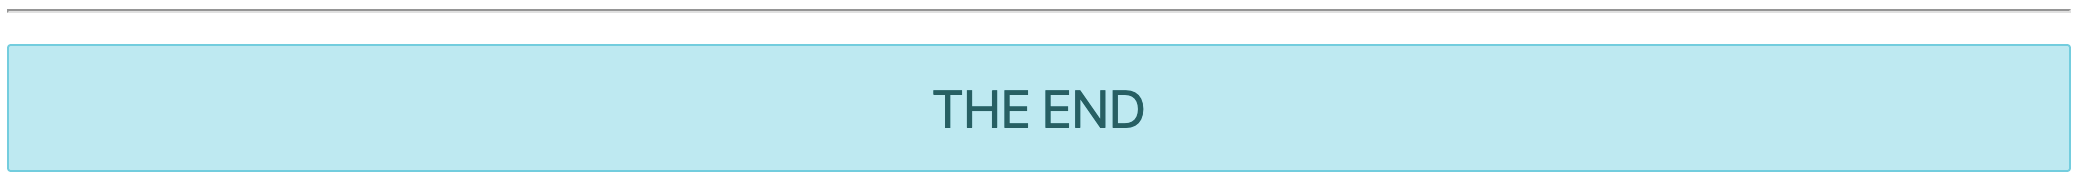